Скачаем необходимые библиотеки

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

Скачаем, распакуем и удалим архив

In [73]:
!unzip -q data.zip
!rm data.zip

## Загрузка и предобработка датасетов

### Загрузка и предобработка контекстных данных

In [74]:
context_data = pd.read_excel('Kont_dannyeOO.xlsx', header=0, index_col=0)
context_data

,Где расположена образовательная организация?,Наименование населенного пункта,Размер населенного пункта,ОО является специальной (коррекционной),Количество обучающихся в ОО (в сумме по всем классам)
Логин ОО,,,,,
Логин ОО,NaN,NaN,NaN,NaN,NaN
sch05153602,"4. Населенный пункт сельского типа (село, хуто...",село Шумлелик,1. Менее 1 тыс. человек,Нет,207
sch05153601,"4. Населенный пункт сельского типа (село, хуто...",Червленные-буруны,2. 1–5 тыс. человек,Да,287
sch05153598,"4. Населенный пункт сельского типа (село, хуто...",Ортатюбе,3. 5–10 тыс. чел,Нет,110
sch05153594,"4. Населенный пункт сельского типа (село, хуто...",Кумли,1. Менее 1 тыс. человек,Нет,96
...,...,...,...,...,...
sch62126033,"4. Населенный пункт сельского типа (село, хуто...",Новая Деревня,1. Менее 1 тыс. человек,Нет,32
sch63130094,"4. Населенный пункт сельского типа (село, хуто...",Кабановка,2. 1–5 тыс. человек,Нет,75
sch63133298,"4. Населенный пункт сельского типа (село, хуто...",Черновский,2. 1–5 тыс. человек,Нет,3110


Удалим первую строку

In [75]:
context_data.drop(index=context_data.index[0], axis=0, inplace=True)

Переимнуем названия колонок на что-то более короткое

In [76]:
context_data.rename(columns={
      'Где расположена образовательная организация?': 'locality_type',
      'Наименование населенного пункта': 'locality_name',
      'Размер населенного пункта': 'population',
      'ОО является специальной (коррекционной)': 'correction',
      'Количество обучающихся в ОО (в сумме по всем классам)': 'pupils_amount'
  }, inplace=True)

Поменяем название индекса

In [77]:
context_data.index.name = 'login'

In [78]:
context_data

,locality_type,locality_name,population,correction,pupils_amount
login,,,,,
sch05153602,"4. Населенный пункт сельского типа (село, хуто...",село Шумлелик,1. Менее 1 тыс. человек,Нет,207
sch05153601,"4. Населенный пункт сельского типа (село, хуто...",Червленные-буруны,2. 1–5 тыс. человек,Да,287
sch05153598,"4. Населенный пункт сельского типа (село, хуто...",Ортатюбе,3. 5–10 тыс. чел,Нет,110
sch05153594,"4. Населенный пункт сельского типа (село, хуто...",Кумли,1. Менее 1 тыс. человек,Нет,96
sch05153592,"4. Населенный пункт сельского типа (село, хуто...",Карагас,2. 1–5 тыс. человек,Нет,220
...,...,...,...,...,...
sch62126033,"4. Населенный пункт сельского типа (село, хуто...",Новая Деревня,1. Менее 1 тыс. человек,Нет,32
sch63130094,"4. Населенный пункт сельского типа (село, хуто...",Кабановка,2. 1–5 тыс. человек,Нет,75
sch63133298,"4. Населенный пункт сельского типа (село, хуто...",Черновский,2. 1–5 тыс. человек,Нет,3110


В колонке pupils_amount есть 2 записи, содержащие нецелочисленные значения, удалим их

In [79]:
context_data.drop(context_data[context_data['pupils_amount'].astype(str).str.isnumeric() == False].index, inplace=True)
context_data

,locality_type,locality_name,population,correction,pupils_amount
login,,,,,
sch05153602,"4. Населенный пункт сельского типа (село, хуто...",село Шумлелик,1. Менее 1 тыс. человек,Нет,207
sch05153601,"4. Населенный пункт сельского типа (село, хуто...",Червленные-буруны,2. 1–5 тыс. человек,Да,287
sch05153598,"4. Населенный пункт сельского типа (село, хуто...",Ортатюбе,3. 5–10 тыс. чел,Нет,110
sch05153594,"4. Населенный пункт сельского типа (село, хуто...",Кумли,1. Менее 1 тыс. человек,Нет,96
sch05153592,"4. Населенный пункт сельского типа (село, хуто...",Карагас,2. 1–5 тыс. человек,Нет,220
...,...,...,...,...,...
sch62126033,"4. Населенный пункт сельского типа (село, хуто...",Новая Деревня,1. Менее 1 тыс. человек,Нет,32
sch63130094,"4. Населенный пункт сельского типа (село, хуто...",Кабановка,2. 1–5 тыс. человек,Нет,75
sch63133298,"4. Населенный пункт сельского типа (село, хуто...",Черновский,2. 1–5 тыс. человек,Нет,3110


Видоизменим колонки locality_type и population (какие-то категории объединим, и при этом изменим у всех названия)

In [80]:
population_mapping = {
    '1. Менее 1 тыс. человек': '0-1.000',
    '2. 1–5 тыс. человек': '1.000-10.000',
    '3. 5–10 тыс. чел': '1.000-10.000',
    '4. 10–50 тыс. человек': '10.000-100.000',
    '5. 50–100 тыс. человек': '10.000-100.000',
    '6. 100–450 тыс. человек': '100.000+',
    '7. 450–680 тыс. человек': '100.000+',
    '8. Более 680 тыс. человек': '100.000+'
}

In [81]:
locality_mapping = {
    '1. Столица субъекта РФ': 'Столица субъекта РФ',
    '2. Город': 'Город',
    '3. Населенный пункт городского типа (рабочий поселок, поселок городского типа и пр.)': 'НПГТ',
    '4. Населенный пункт сельского типа (село, хутор, деревня и пр.)': 'НПСТ'
}

In [82]:
context_data['locality_type'] = context_data['locality_type'].apply(lambda x: locality_mapping[x])
context_data['population'] = context_data['population'].apply(lambda x: population_mapping[x])

В колонке про то, является ли школа коррекционной, существует 4 различных значения

In [83]:
context_data['correction'].unique()

array(['Нет', 'Да', 'нет', 'да'], dtype=object)

Следует привести всё к нижнему регистру, а затем бинарно закодировать переменные

In [84]:
context_data['correction'] = context_data['correction'].str.lower()
context_data.replace({'correction': {'да': 1, 'нет': 0}}, inplace=True)

/tmp/ipykernel_1538/2873005213.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  context_data.replace({'correction': {'да': 1, 'нет': 0}}, inplace=True)


In [85]:
context_data

,locality_type,locality_name,population,correction,pupils_amount
login,,,,,
sch05153602,НПСТ,село Шумлелик,0-1.000,0,207
sch05153601,НПСТ,Червленные-буруны,1.000-10.000,1,287
sch05153598,НПСТ,Ортатюбе,1.000-10.000,0,110
sch05153594,НПСТ,Кумли,0-1.000,0,96
sch05153592,НПСТ,Карагас,1.000-10.000,0,220
...,...,...,...,...,...
sch62126033,НПСТ,Новая Деревня,0-1.000,0,32
sch63130094,НПСТ,Кабановка,1.000-10.000,0,75
sch63133298,НПСТ,Черновский,1.000-10.000,0,3110


Добавим ещё один признак - округ, в котором находится школа (для этого сначала определим регион, в котором она находится)

In [86]:
context_data['region'] = context_data.index.str[3:5].astype(int)
context_data

,locality_type,locality_name,population,correction,pupils_amount,region
login,,,,,,
sch05153602,НПСТ,село Шумлелик,0-1.000,0,207,5
sch05153601,НПСТ,Червленные-буруны,1.000-10.000,1,287,5
sch05153598,НПСТ,Ортатюбе,1.000-10.000,0,110,5
sch05153594,НПСТ,Кумли,0-1.000,0,96,5
sch05153592,НПСТ,Карагас,1.000-10.000,0,220,5
...,...,...,...,...,...,...
sch62126033,НПСТ,Новая Деревня,0-1.000,0,32,62
sch63130094,НПСТ,Кабановка,1.000-10.000,0,75,63
sch63133298,НПСТ,Черновский,1.000-10.000,0,3110,63


Создадим таблицу с номерами и соответствующими им Федеральными округами

In [87]:
districts = pd.DataFrame({
    'district': ['ЦФО', 'СЗФО', 'ЮФО', 'СКФО', 'ПФО', 'УрФО', 'СФО', 'ДВФО', 'Севастополь', 'За пределами РФ']
}, index=np.arange(1, 11))
districts.index.name = 'district code'
districts

,district
district code,
1,ЦФО
2,СЗФО
3,ЮФО
4,СКФО
5,ПФО
6,УрФО
7,СФО
8,ДВФО
9,Севастополь


In [88]:
context_data['district'] = context_data['region'].replace({
    1: 3,  2: 5,  3: 7,  4: 7,  5: 4,  6: 4,  7: 4,  8: 3,  9: 4, 10: 2, 11: 2, 12: 5, 13: 5, 14: 8, 15: 4, 16: 5, 17: 7,
    18: 5, 19: 7, 20: 4, 21: 5, 22: 7, 23: 3, 24: 7, 25: 8, 26: 4, 27: 8, 28: 8, 29: 2, 30: 3, 31: 1, 32: 1, 33: 1, 34: 3,
    35: 2, 36: 1, 37: 1, 38: 7, 39: 2, 40: 1, 41: 8, 42: 7, 43: 5, 44: 1, 45: 6, 46: 1, 47: 2, 48: 1, 49: 8, 50: 1, 51: 2,
    52: 5, 53: 2, 54: 7, 55: 7, 56: 5, 57: 1, 58: 5, 59: 5, 60: 2, 61: 3, 62: 1, 63: 5, 64: 5, 65: 8, 66: 6, 67: 1, 68: 1,
    69: 1, 70: 7, 71: 1, 72: 6, 73: 5, 74: 6, 75: 7, 76: 1, 77: 1, 78: 2, 79: 8, 82: 3, 83: 2, 86: 6, 87: 8, 89: 6, 90: 10,
    92: 9
})
context_data

,locality_type,locality_name,population,correction,pupils_amount,region,district
login,,,,,,,
sch05153602,НПСТ,село Шумлелик,0-1.000,0,207,5,4
sch05153601,НПСТ,Червленные-буруны,1.000-10.000,1,287,5,4
sch05153598,НПСТ,Ортатюбе,1.000-10.000,0,110,5,4
sch05153594,НПСТ,Кумли,0-1.000,0,96,5,4
sch05153592,НПСТ,Карагас,1.000-10.000,0,220,5,4
...,...,...,...,...,...,...,...
sch62126033,НПСТ,Новая Деревня,0-1.000,0,32,62,1
sch63130094,НПСТ,Кабановка,1.000-10.000,0,75,63,5
sch63133298,НПСТ,Черновский,1.000-10.000,0,3110,63,5


Заменим код региона его аббревиатурой

In [89]:
context_data['district'] = context_data['district'].apply(lambda x: districts.loc[x].values[0])

Удалим признак региона

In [90]:
context_data = context_data.drop(columns='region')
context_data

,locality_type,locality_name,population,correction,pupils_amount,district
login,,,,,,
sch05153602,НПСТ,село Шумлелик,0-1.000,0,207,СКФО
sch05153601,НПСТ,Червленные-буруны,1.000-10.000,1,287,СКФО
sch05153598,НПСТ,Ортатюбе,1.000-10.000,0,110,СКФО
sch05153594,НПСТ,Кумли,0-1.000,0,96,СКФО
sch05153592,НПСТ,Карагас,1.000-10.000,0,220,СКФО
...,...,...,...,...,...,...
sch62126033,НПСТ,Новая Деревня,0-1.000,0,32,ЦФО
sch63130094,НПСТ,Кабановка,1.000-10.000,0,75,ПФО
sch63133298,НПСТ,Черновский,1.000-10.000,0,3110,ПФО


### Загрузка и предобработка результатов учеников

In [91]:
pupils = pd.read_csv('pupils_ruma456_2019_2020.csv')

/tmp/ipykernel_1538/413649574.py:1: DtypeWarning: Columns (0,1,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  pupils = pd.read_csv('pupils_ruma456_2019_2020.csv')


In [92]:
pupils

,Класс,Код_предмета,ЛогинОО,Код_ученика,Балл,Отметка,Year
0,4,2,sch01110001,4001,11,4,2019
1,4,2,sch01110001,4002,18,5,2019
2,4,2,sch01110001,4003,9,3,2019
3,4,2,sch01110001,4004,11,4,2019
4,4,2,sch01110001,4005,8,3,2019
...,...,...,...,...,...,...,...
11221344,5,1,sch87176023,50212,10,2,2020
11221345,5,1,sch87176023,50213,21,3,2020
11221346,5,1,sch87176023,50214,21,3,2020
11221347,5,1,sch87176023,50216,21,3,2020


Переименуем колонки

In [93]:
pupils.rename(columns={
      'Класс': 'class',
      'Код_предмета': 'subject',
      'ЛогинОО': 'login',
      'Код_ученика': 'pupil_code',
      'Балл': 'point',
      'Отметка': 'mark',
      'Year': 'year'
  }, inplace=True)

Посмотрим на типы данных

In [94]:
pupils.dtypes

,0
class,object
subject,object
login,object
pupil_code,object
point,object
mark,object
year,int64


По-хорошему, все данные за исключением логина образовательной организации, должны иметь целочисленный тип. Давайте посмотрим на уникальные значения

Немного поисследовав данные, я нашёл, что было причиной тому, что числовые данные имели строковой тип - в исходной таблице есть строки, у которых вместо значений пробелы. Удалим их

In [95]:
pupils[pupils['class'] == ' ']

,class,subject,login,pupil_code,point,mark,year
7284166,,,GUID .,,,,2020
8587100,,,GUID .,,,,2020
9891879,,,GUID .,,,,2020


In [96]:
pupils.drop(pupils[pupils['class'] == ' '].index, inplace=True)

Теперь всё пусто

In [97]:
pupils[pupils['class'] == ' ']

,class,subject,login,pupil_code,point,mark,year


Следующая проблема - некоторые значения столбцов имеют одинаковые метки разных типов. Это хорошо видно на примере столбца mark

In [98]:
pupils['mark'].value_counts()

,count
mark,
4,4075350
3,3326526
5,2038790
2,1145613
0,241854
3,144360
4,137158
2,54674
5,51899


То есть оценки существуют сразу в двух видах - числовом и строковом

Исправим это, приведя значения всех колонок за исключеним login к числовым

In [99]:
for column_name in pupils.columns.drop('login'):
    pupils[column_name] = pupils[column_name].astype(int)

Теперь всё хорошо

In [100]:
pupils

,class,subject,login,pupil_code,point,mark,year
0,4,2,sch01110001,4001,11,4,2019
1,4,2,sch01110001,4002,18,5,2019
2,4,2,sch01110001,4003,9,3,2019
3,4,2,sch01110001,4004,11,4,2019
4,4,2,sch01110001,4005,8,3,2019
...,...,...,...,...,...,...,...
11221344,5,1,sch87176023,50212,10,2,2020
11221345,5,1,sch87176023,50213,21,3,2020
11221346,5,1,sch87176023,50214,21,3,2020
11221347,5,1,sch87176023,50216,21,3,2020


Сопоставим коду предмета его сокращённое название

In [101]:
subject_mapping = {
    1: 'rus',
    2: 'math'
}

In [102]:
pupils['subject'] = pupils['subject'].apply(lambda x: subject_mapping[x])

In [103]:
pupils

,class,subject,login,pupil_code,point,mark,year
0,4,math,sch01110001,4001,11,4,2019
1,4,math,sch01110001,4002,18,5,2019
2,4,math,sch01110001,4003,9,3,2019
3,4,math,sch01110001,4004,11,4,2019
4,4,math,sch01110001,4005,8,3,2019
...,...,...,...,...,...,...,...
11221344,5,rus,sch87176023,50212,10,2,2020
11221345,5,rus,sch87176023,50213,21,3,2020
11221346,5,rus,sch87176023,50214,21,3,2020
11221347,5,rus,sch87176023,50216,21,3,2020


## Подсчёт среднего балла для всех школ по русскому языку и математике по различным разбиениям

Соединим информацию о учениках и контекстные данные

In [104]:
joined = pupils.merge(context_data, how='left', on='login')
joined

,class,subject,login,pupil_code,point,mark,year,locality_type,locality_name,population,correction,pupils_amount,district
0,4,math,sch01110001,4001,11,4,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
1,4,math,sch01110001,4002,18,5,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
2,4,math,sch01110001,4003,9,3,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
3,4,math,sch01110001,4004,11,4,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
4,4,math,sch01110001,4005,8,3,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11221341,5,rus,sch87176023,50212,10,2,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО
11221342,5,rus,sch87176023,50213,21,3,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО
11221343,5,rus,sch87176023,50214,21,3,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО
11221344,5,rus,sch87176023,50216,21,3,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО


Посмотрим на уникальные значения признака population

In [105]:
joined['population'].unique()

array(['10.000-100.000', '1.000-10.000', '0-1.000', nan, '100.000+'],
      dtype=object)

Замечаем, что присутствует NaN, попробуем вывести все строки с NaN в столбце population

In [106]:
joined[joined['population'].isna()]

,class,subject,login,pupil_code,point,mark,year,locality_type,locality_name,population,correction,pupils_amount,district
980,4,math,sch01110040,4001,16,5,2019,NaN,NaN,NaN,NaN,NaN,NaN
981,4,math,sch01110040,4002,3,2,2019,NaN,NaN,NaN,NaN,NaN,NaN
982,4,math,sch01110040,4003,10,4,2019,NaN,NaN,NaN,NaN,NaN,NaN
1000,4,math,sch01110045,4001,12,4,2019,NaN,NaN,NaN,NaN,NaN,NaN
1001,4,math,sch01110045,4002,18,5,2019,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11221068,5,rus,sch77179669,50002,26,4,2020,NaN,NaN,NaN,NaN,NaN,NaN
11221069,5,rus,sch77179669,50003,26,4,2020,NaN,NaN,NaN,NaN,NaN,NaN
11221070,5,rus,sch77179669,50004,26,4,2020,NaN,NaN,NaN,NaN,NaN,NaN
11221203,5,rus,sch02123903,50001,14,3,2020,NaN,NaN,NaN,NaN,NaN,NaN


Также NaN присутствует во признаках, присутствующих в контекстных данных. Отсюда можно сделать вывод, что информация про некоторые школы отсутствует в таблице с информацией про результаты учеников. Удалим все такие школы

In [107]:
joined.dropna(subset=['locality_type', 'locality_name', 'population', 'correction', 'pupils_amount'], inplace=True)
joined

,class,subject,login,pupil_code,point,mark,year,locality_type,locality_name,population,correction,pupils_amount,district
0,4,math,sch01110001,4001,11,4,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
1,4,math,sch01110001,4002,18,5,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
2,4,math,sch01110001,4003,9,3,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
3,4,math,sch01110001,4004,11,4,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
4,4,math,sch01110001,4005,8,3,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11221341,5,rus,sch87176023,50212,10,2,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО
11221342,5,rus,sch87176023,50213,21,3,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО
11221343,5,rus,sch87176023,50214,21,3,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО
11221344,5,rus,sch87176023,50216,21,3,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО


Изменим тип признака correction на int

In [108]:
joined.loc[:, ['correction']] = joined['correction'].astype(int)
joined

,class,subject,login,pupil_code,point,mark,year,locality_type,locality_name,population,correction,pupils_amount,district
0,4,math,sch01110001,4001,11,4,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
1,4,math,sch01110001,4002,18,5,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
2,4,math,sch01110001,4003,9,3,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
3,4,math,sch01110001,4004,11,4,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
4,4,math,sch01110001,4005,8,3,2019,НПСТ,Гиагинская,10.000-100.000,0.0,611,ЮФО
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11221341,5,rus,sch87176023,50212,10,2,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО
11221342,5,rus,sch87176023,50213,21,3,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО
11221343,5,rus,sch87176023,50214,21,3,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО
11221344,5,rus,sch87176023,50216,21,3,2020,Столица субъекта РФ,Анадырь,10.000-100.000,0.0,975,ДВФО


Проверим, что не осталось пустых значений

In [109]:
joined.isna().sum()

,0
class,0
subject,0
login,0
pupil_code,0
point,0
mark,0
year,0
locality_type,0
locality_name,0
population,0


### Группировка по типу населённого пункта

Сгруппируем таблицу по признакам класса, предмету, году и типу населённого пункта

In [110]:
grouped_locality = joined.groupby(['class', 'subject', 'year', 'locality_type']).apply(lambda x: x['point'].mean()).reset_index().rename(columns={0: 'point'})
grouped_locality

/tmp/ipykernel_1538/4122969872.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_locality = joined.groupby(['class', 'subject', 'year', 'locality_type']).apply(lambda x: x['point'].mean()).reset_index().rename(columns={0: 'point'})


,class,subject,year,locality_type,point
0,4,math,2019,Город,13.161256
1,4,math,2019,НПГТ,12.417105
2,4,math,2019,НПСТ,11.840573
3,4,math,2019,Столица субъекта РФ,13.757586
4,4,rus,2019,Город,27.123030
5,4,rus,2019,НПГТ,25.944107
6,4,rus,2019,НПСТ,24.859808
7,4,rus,2019,Столица субъекта РФ,27.886186
8,5,math,2019,Город,10.875846
9,5,math,2019,НПГТ,10.256974


Определим функцию для отрисовки графиков средних баллов

In [111]:
def mean_points(dataframe, subject, subject_name, hue):
    fig, axs = plt.subplots(figsize=(15,7), ncols=2)
    sns.barplot(data=dataframe[(dataframe['subject'] == subject) & (dataframe['year'] == 2019)], x='class', y='point', hue=hue, legend=False, ax=axs[0]).set(title=subject_name + ', 2019')
    sns.barplot(data=dataframe[(dataframe['subject'] == subject) & (dataframe['year'] == 2020)], x='class', y='point', hue=hue, legend='full', ax=axs[1]).set(title=subject_name + ', 2020')
    sns.move_legend(axs[1], "upper left", bbox_to_anchor=(1, 1))
    plt.show()

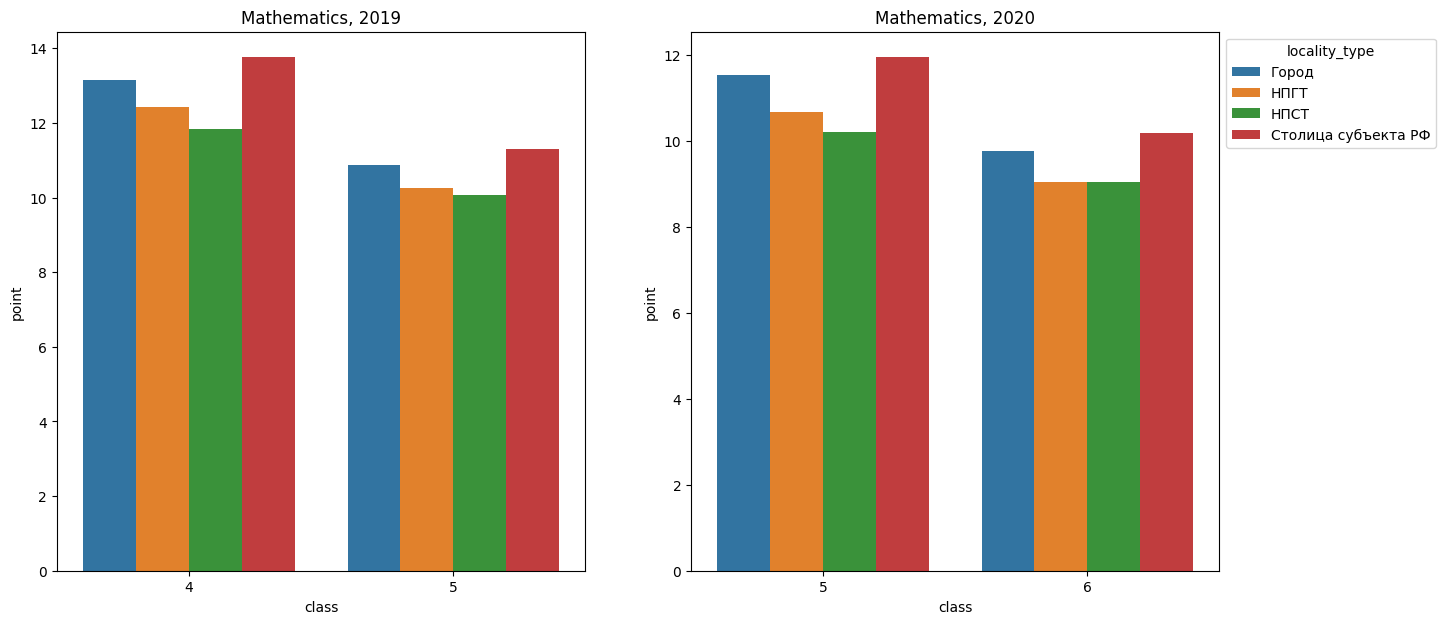

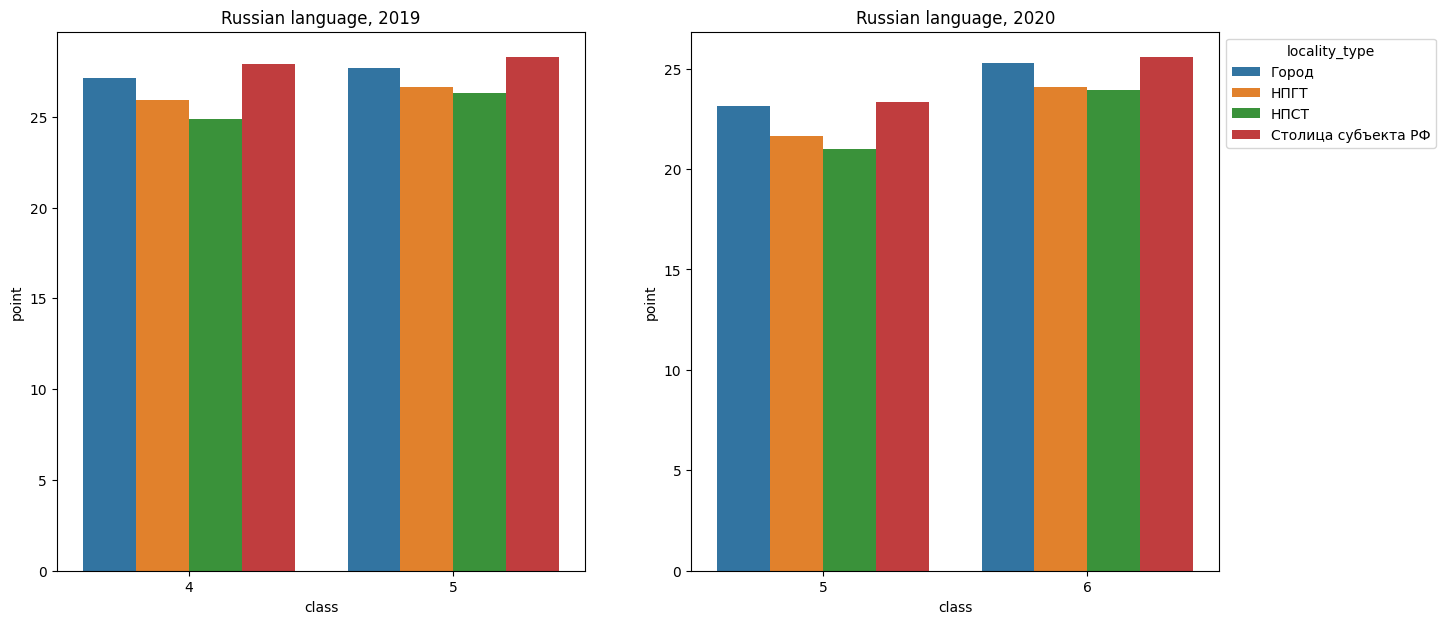

In [112]:
for subject, subject_name in zip(['math', 'rus'], ['Mathematics', 'Russian language']):
    mean_points(grouped_locality, subject, subject_name, 'locality_type')

Видим, что средний балл уменьшается с уменьшением размера населённого пункта (то есть например в столице субъекта РФ результат лучше, чем в населённом пункте сельского типа) у каждого класса по обоим предметам за каждый год

Если по русскому языку это может быть связано с тем, что в ВПР 4 классе количество баллов меньше, чем в 5 и 6 и набрать их соответственно легче, то по математике это в большей степени скорее всего объясняется возросшей сложностью работы

### Группировка по количеству населения населённого пункта

Сгруппируем таблицу по признакам класса, коду предмета, году и численности населения населённого пункта

In [113]:
grouped_population = joined.groupby(['class', 'subject', 'year', 'population']).apply(lambda x: x['point'].mean()).reset_index().rename(columns={0: 'point'})
grouped_population

/tmp/ipykernel_1538/3936006716.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_population = joined.groupby(['class', 'subject', 'year', 'population']).apply(lambda x: x['point'].mean()).reset_index().rename(columns={0: 'point'})


,class,subject,year,population,point
0,4,math,2019,0-1.000,11.682991
1,4,math,2019,1.000-10.000,12.028094
2,4,math,2019,10.000-100.000,12.676588
3,4,math,2019,100.000+,13.473238
4,4,rus,2019,0-1.000,24.401559
5,4,rus,2019,1.000-10.000,25.239661
6,4,rus,2019,10.000-100.000,26.432782
7,4,rus,2019,100.000+,27.537298
8,5,math,2019,0-1.000,10.291671
9,5,math,2019,1.000-10.000,10.052724


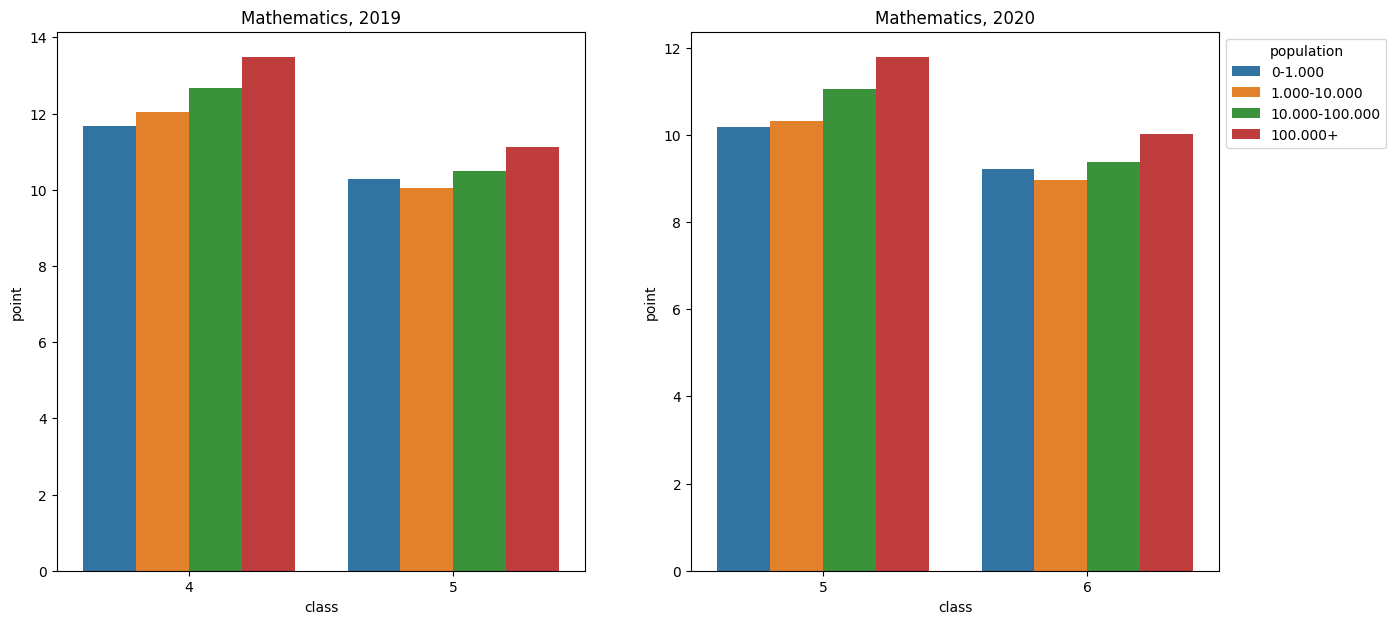

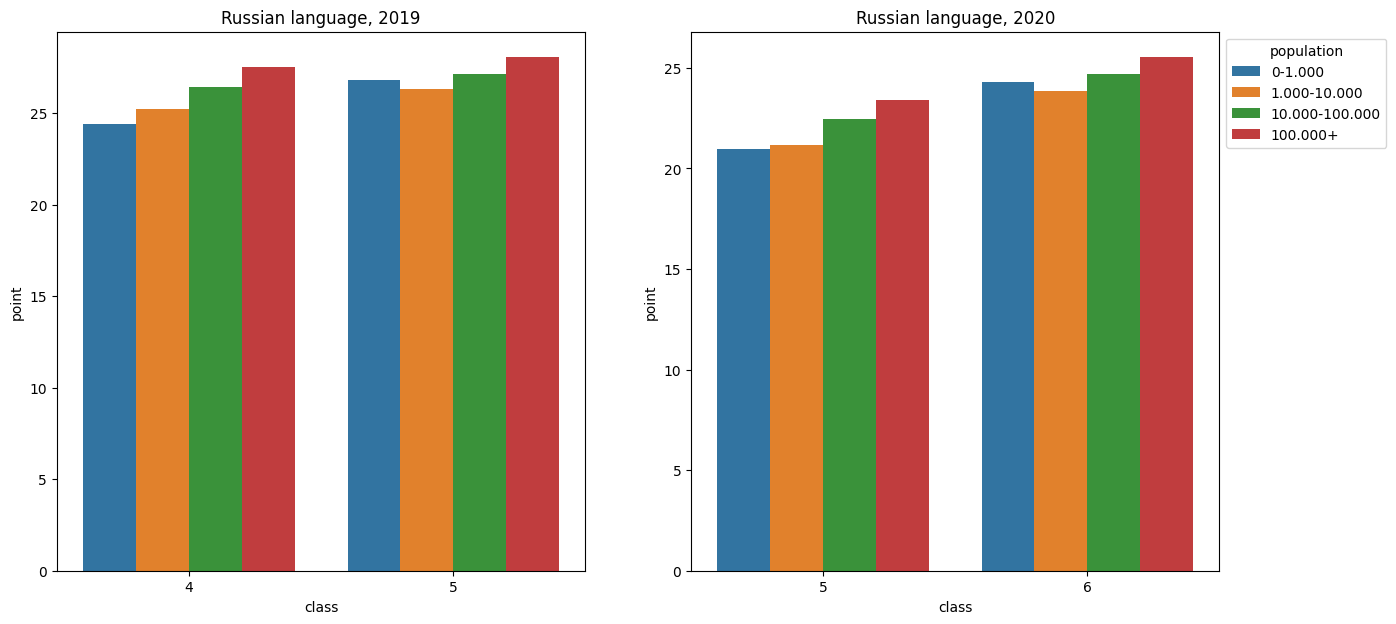

In [114]:
for subject, subject_name in zip(['math', 'rus'], ['Mathematics', 'Russian language']):
    mean_points(grouped_population, subject, subject_name, 'population')

В принципе, видим аналогичную картину той, что наблюдали в случае с группировкой по типу населённого пункта - с увеличением численности населения результаты растут (лишь в 4 случаях результаты в населённых пунктах с численностью населения меньше 1000 человек больше, чем в населённых пунктах с численностью населения от 1000 до 5000 человек)

### Группировка по типу школы

Сгруппируем таблицу по признакам класса, кода предмета, году и типу школы

In [115]:
grouped_сorrection = joined.groupby(['class', 'subject', 'year', 'correction']).apply(lambda x: x['point'].mean()).reset_index().rename(columns={0: 'point'})
grouped_сorrection

/tmp/ipykernel_1538/1143579741.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_сorrection = joined.groupby(['class', 'subject', 'year', 'correction']).apply(lambda x: x['point'].mean()).reset_index().rename(columns={0: 'point'})


,class,subject,year,correction,point
0,4,math,2019,0.0,12.858760
1,4,math,2019,1.0,12.548623
2,4,rus,2019,0.0,26.586566
3,4,rus,2019,1.0,25.852634
4,5,math,2019,0.0,10.683522
5,5,math,2019,1.0,10.445295
6,5,math,2020,0.0,11.183988
7,5,math,2020,1.0,11.006453
8,5,rus,2019,0.0,27.355529
9,5,rus,2019,1.0,27.208699


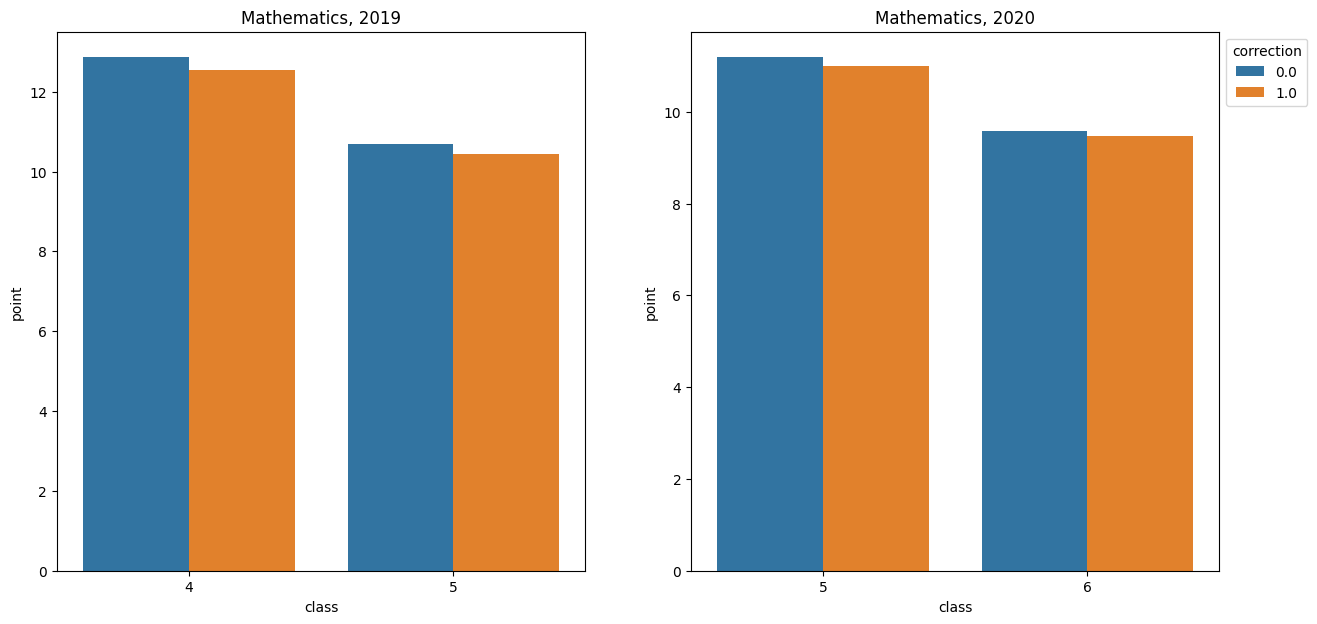

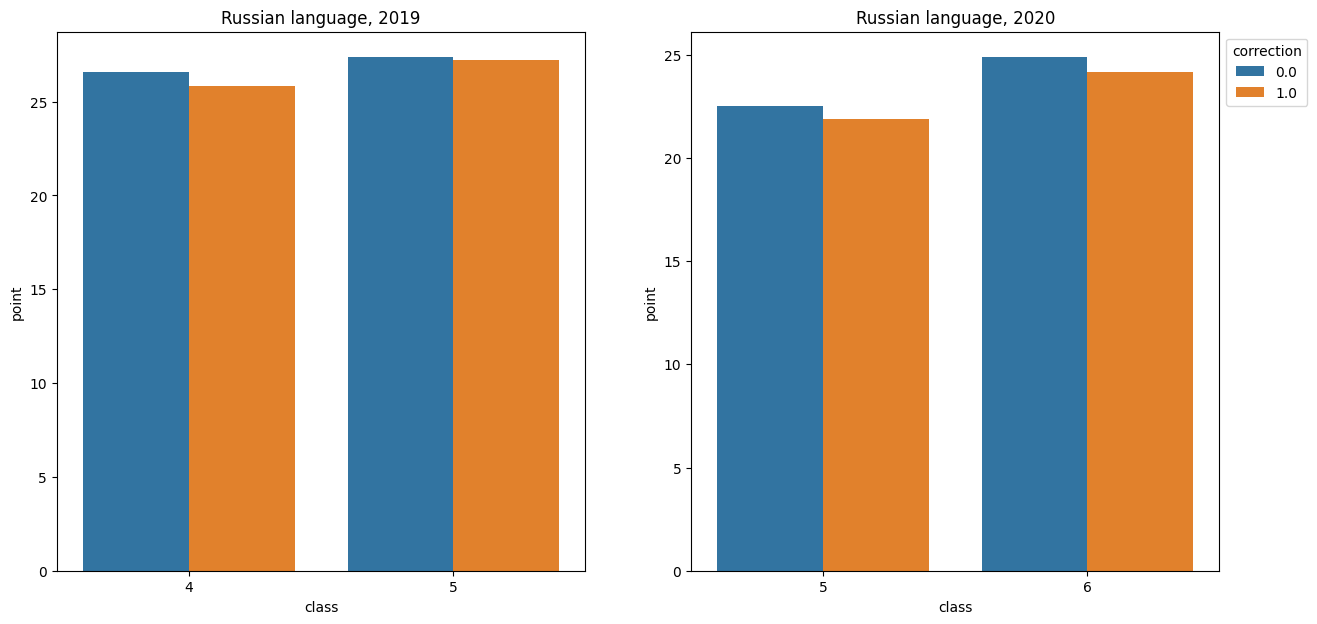

In [116]:
for subject, subject_name in zip(['math', 'rus'], ['Mathematics', 'Russian language']):
    mean_points(grouped_сorrection, subject, subject_name, 'correction')

У коррекционных школ результаты конечно ниже, чем у обычных, но на удивление разница довольно мала

### Группировка по номеру округа

Сгруппируем таблицу по признакам класса, коду предмета, году и округу

In [117]:
grouped_district = joined.groupby(['class', 'subject', 'year', 'district']).apply(lambda x: x['point'].mean()).reset_index().rename(columns={0: 'point'})
grouped_district

/tmp/ipykernel_1538/2288746240.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_district = joined.groupby(['class', 'subject', 'year', 'district']).apply(lambda x: x['point'].mean()).reset_index().rename(columns={0: 'point'})


,class,subject,year,district,point
0,4,math,2019,ДВФО,12.601083
1,4,math,2019,За пределами РФ,14.531873
2,4,math,2019,ПФО,13.177298
3,4,math,2019,СЗФО,13.395547
4,4,math,2019,СКФО,11.777009
...,...,...,...,...,...
75,6,rus,2020,СФО,23.143267
76,6,rus,2020,Севастополь,23.493979
77,6,rus,2020,УрФО,23.837474
78,6,rus,2020,ЦФО,26.471151


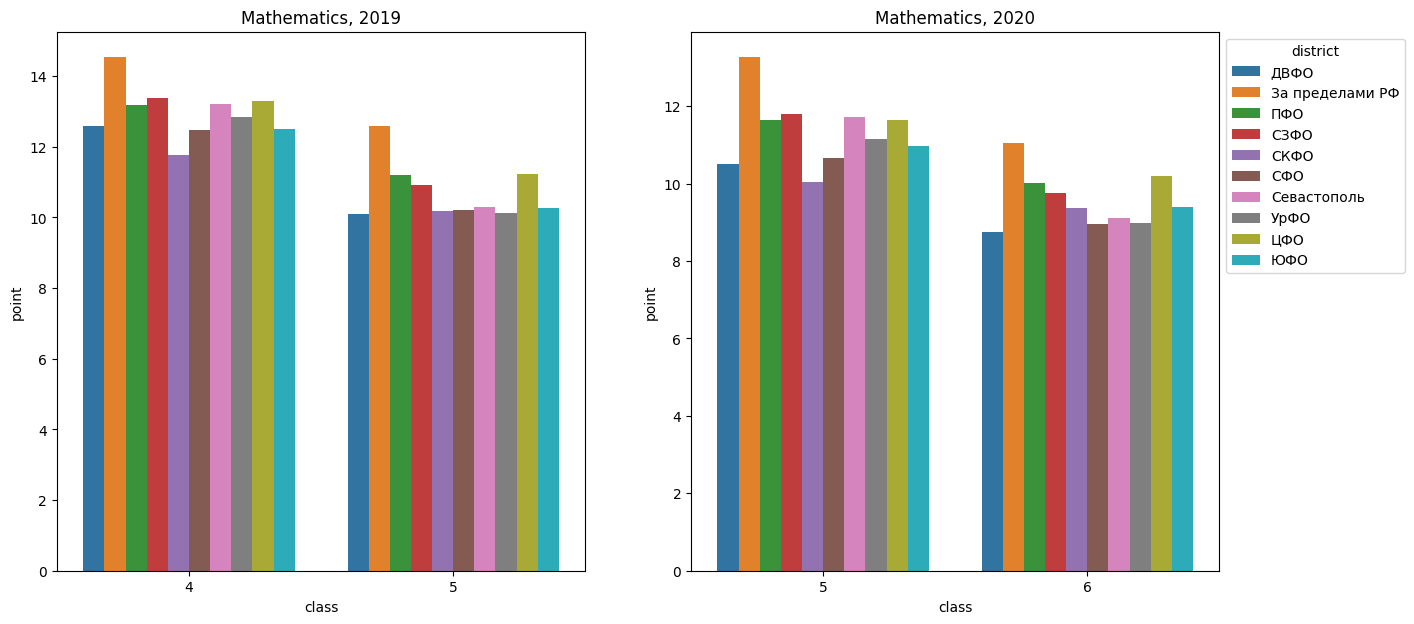

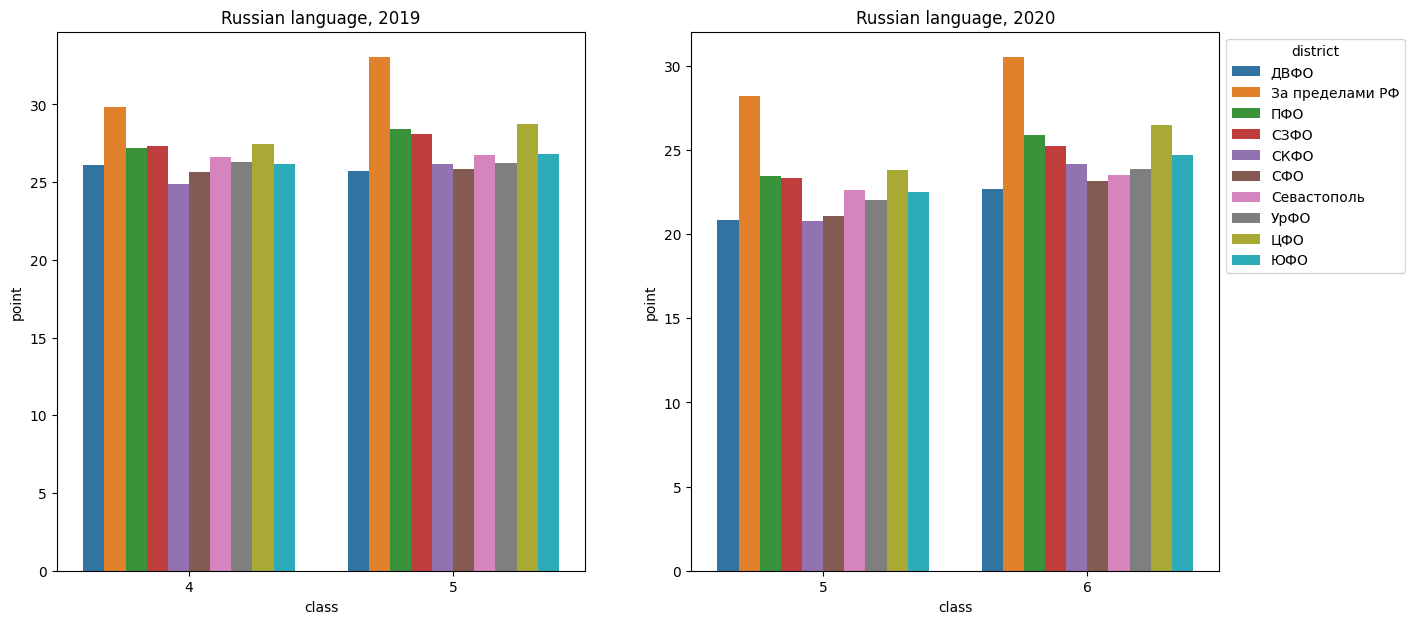

In [118]:
for subject, subject_name in zip(['math', 'rus'], ['Mathematics', 'Russian language']):
    mean_points(grouped_district, subject, subject_name, 'district')

Видим, что Южный, Северо-Кавказский, Сибирский и Дальневосточный округа обычно демонстрируют более низкую успеваемость по сравнению с другими округами. Замечаем также, что самые лучшие результаты демонстрируют ученики из русскоязычных школ, находящихся за пределами РФ - это можно объяснить тем, что как правило такие школы находятся при российских посольствах и учатся там дети людей, работающих в них. Такие дети имеют более высокий уроень образования и качество знаний

## Получение итогового датасета для дальнейшего обучения

Рассчитаем средний балл по школам для русского языка и математики по 4, 5 и 6 классам по 2019 и 2020 году отдельно

In [119]:
grouped_schools = joined.groupby(['class', 'subject', 'year', 'login']).apply(lambda x: x['point'].mean()).reset_index().rename(columns={0: 'point'})
grouped_schools

/tmp/ipykernel_1538/501133706.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_schools = joined.groupby(['class', 'subject', 'year', 'login']).apply(lambda x: x['point'].mean()).reset_index().rename(columns={0: 'point'})


,class,subject,year,login,point
0,4,math,2019,sch01110001,11.826087
1,4,math,2019,sch01110003,13.365385
2,4,math,2019,sch01110004,12.897059
3,4,math,2019,sch01110005,9.608696
4,4,math,2019,sch01110006,12.769231
...,...,...,...,...,...
271842,6,rus,2020,sch92122008,20.960000
271843,6,rus,2020,sch92126001,27.790123
271844,6,rus,2020,sch92126007,19.763359
271845,6,rus,2020,sch92126013,24.768657


По математике можно набрать максимум 20 баллов (для всех классов), а для русского языка - 38 баллов могут набрать четероклассники, а 45 - пяти- и шестиклассники

Получается, что у признаков средних баллов разные масштабы, и лучше перевести эти средние баллы в проценты выполнения

In [120]:
grouped_schools.loc[grouped_schools['subject'] == 'math', 'point'] /= 20
grouped_schools.loc[(grouped_schools['subject'] == 'rus') & (grouped_schools['class'] == 4), 'point'] /= 38
grouped_schools.loc[(grouped_schools['subject'] == 'rus') & (grouped_schools['class'] > 4), 'point'] /= 45

In [121]:
grouped_schools

,class,subject,year,login,point
0,4,math,2019,sch01110001,0.591304
1,4,math,2019,sch01110003,0.668269
2,4,math,2019,sch01110004,0.644853
3,4,math,2019,sch01110005,0.480435
4,4,math,2019,sch01110006,0.638462
...,...,...,...,...,...
271842,6,rus,2020,sch92122008,0.465778
271843,6,rus,2020,sch92126001,0.617558
271844,6,rus,2020,sch92126007,0.439186
271845,6,rus,2020,sch92126013,0.550415


В промежуточной таблице будут средние баллы за 2019 и 2020 годы в отдельных колонках

In [122]:
inter = pd.pivot_table(grouped_schools, values='point', columns=['year', 'class'], index='login').reset_index()
inter

year         login      2019                2020          
class                      4         5         5         6
0      ksh38180031       NaN       NaN  0.562118  0.590952
1      sch01110001  0.649903  0.497187  0.561805  0.500325
2      sch01110003  0.668047  0.554611  0.490556  0.538653
3      sch01110004  0.618985  0.574902  0.446588  0.461892
4      sch01110005  0.572089  0.636389  0.480952  0.544823
...            ...       ...       ...       ...       ...
35719  sch92122008  0.547579  0.655629  0.513590  0.415889
35720  sch92126001  0.722316  0.611254  0.565428  0.585645
35721  sch92126007  0.604244  0.588265  0.535207  0.352285
35722  sch92126013       NaN       NaN  0.609477  0.562059
35723  spo66160020       NaN       NaN       NaN  0.509722

[35724 rows x 5 columns]

Объединим таблицы grouped_mean_points_classes, inter, inter_2019 и inter_2020 по логину школ

In [123]:
inter_2019, inter_2020 = inter[2019], inter[2020]
inter_2019.columns = inter_2019.columns.get_level_values(0)
inter_2019 = inter_2019.rename(columns={
    4: '2019_4',
    5: '2019_5'
})
inter_2020.columns = inter_2020.columns.get_level_values(0)
inter_2020 = inter_2020.rename(columns={
    5: '2020_5',
    6: '2020_6'
})
grouped_mean_points_classes = pd.concat((inter[['login']], inter_2019, inter_2020), axis=1).rename(columns={
    ('login', ''): 'login',
})
grouped_mean_points_classes

,login,2019_4,2019_5,2020_5,2020_6
0,ksh38180031,NaN,NaN,0.562118,0.590952
1,sch01110001,0.649903,0.497187,0.561805,0.500325
2,sch01110003,0.668047,0.554611,0.490556,0.538653
3,sch01110004,0.618985,0.574902,0.446588,0.461892
4,sch01110005,0.572089,0.636389,0.480952,0.544823
...,...,...,...,...,...
35719,sch92122008,0.547579,0.655629,0.513590,0.415889
35720,sch92126001,0.722316,0.611254,0.565428,0.585645
35721,sch92126007,0.604244,0.588265,0.535207,0.352285
35722,sch92126013,NaN,NaN,0.609477,0.562059


In [124]:
grouped = grouped_schools.drop(columns=['year', 'point', 'class', 'subject']).drop_duplicates().merge(grouped_mean_points_classes, on='login', how='right').dropna()
grouped

,login,2019_4,2019_5,2020_5,2020_6
1,sch01110001,0.649903,0.497187,0.561805,0.500325
2,sch01110003,0.668047,0.554611,0.490556,0.538653
3,sch01110004,0.618985,0.574902,0.446588,0.461892
4,sch01110005,0.572089,0.636389,0.480952,0.544823
5,sch01110006,0.653661,0.491667,0.440185,0.511004
...,...,...,...,...,...
35716,sch92122004,0.687551,0.673016,0.510880,0.450617
35718,sch92122007,0.738124,0.681667,0.697222,0.676091
35719,sch92122008,0.547579,0.655629,0.513590,0.415889
35720,sch92126001,0.722316,0.611254,0.565428,0.585645


Объединим таблицы grouped и контекстные данные по логину школ

In [125]:
data = grouped.join(context_data.drop(columns='locality_name'), on='login', how='left')
data

,login,2019_4,2019_5,2020_5,2020_6,locality_type,population,correction,pupils_amount,district
1,sch01110001,0.649903,0.497187,0.561805,0.500325,НПСТ,10.000-100.000,0,611,ЮФО
2,sch01110003,0.668047,0.554611,0.490556,0.538653,НПСТ,1.000-10.000,0,419,ЮФО
3,sch01110004,0.618985,0.574902,0.446588,0.461892,НПСТ,10.000-100.000,0,612,ЮФО
4,sch01110005,0.572089,0.636389,0.480952,0.544823,НПСТ,1.000-10.000,0,153,ЮФО
5,sch01110006,0.653661,0.491667,0.440185,0.511004,НПСТ,0-1.000,0,141,ЮФО
...,...,...,...,...,...,...,...,...,...,...
35716,sch92122004,0.687551,0.673016,0.510880,0.450617,Город,100.000+,0,114,Севастополь
35718,sch92122007,0.738124,0.681667,0.697222,0.676091,Город,100.000+,0,103,Севастополь
35719,sch92122008,0.547579,0.655629,0.513590,0.415889,Город,100.000+,0,236,Севастополь
35720,sch92126001,0.722316,0.611254,0.565428,0.585645,Город,100.000+,0,1085,Севастополь


Скачаем датасеты результатов школьников 4-6 классов по русскому языку и математике и рассчитаем их средние баллы по школам

In [126]:
def load_dataset(link):
    return pd.read_csv(link, encoding='cp1251', sep=';', index_col=0).rename(columns={'Class.1': 'Class'}).drop(columns='Year')

In [127]:
rus_4 = load_dataset('4_1_2021.csv')
math_4 = load_dataset('4_2_2021.csv')
rus_5 = load_dataset('5_1_2021.csv')
math_5 = load_dataset('5_2_2021.csv')
rus_6 = load_dataset('6_1_2021.csv')
math_6 = load_dataset('6_2_2021.csv')

Напишем функцию для расчёта среднего балла для каждого класса и каждого предмета (при этом учитывая максимальные значения)

In [128]:
def mean_point(dataset, divisor):
    result = pd.DataFrame(dataset.groupby(dataset.index).apply(lambda x: x['BAL'].mean())).rename(columns={0: 'target'})
    result['target'] = result['target'] / divisor
    result.index.name = 'login'
    return result

In [129]:
mean_point_rus_4 = mean_point(rus_4, 38)
mean_point_math_4 = mean_point(math_4, 20)
mean_point_rus_5 = mean_point(rus_5, 45)
mean_point_math_5 = mean_point(math_5, 20)
mean_point_rus_6 = mean_point(rus_6, 45)
mean_point_math_6 = mean_point(math_6, 20)

Объединим 6 датасетов в один по логину, а затем для каждой школы посчитаем средний балл по всем предметам и классам

In [130]:
targets = pd.concat((mean_point_rus_4, mean_point_math_4, mean_point_rus_5, mean_point_math_5, mean_point_rus_6, mean_point_math_6))
targets = targets.groupby(targets.index)['target'].mean()
targets

,target
login,
ksh38180031,0.722245
sch01110006,0.546055
sch01110012,0.596775
sch01110019,0.562135
sch01110024,0.618053
...,...
sch92120052,0.521130
sch92120059,0.378718
sch92122004,0.650295


Осталось только удалить из датасета признаков школы с теми логинами, которых нет в targets

In [131]:
preprocessed = data.merge(targets, how='right', on='login').dropna(subset={'correction'})
preprocessed['correction'] = preprocessed['correction'].astype(int)
preprocessed

,login,2019_4,2019_5,2020_5,2020_6,locality_type,population,correction,pupils_amount,district,target
1,sch01110006,0.653661,0.491667,0.440185,0.511004,НПСТ,0-1.000,0,141,ЮФО,0.546055
2,sch01110012,0.568520,0.475794,0.442502,0.576481,НПСТ,0-1.000,0,140,ЮФО,0.596775
3,sch01110019,0.533258,0.376126,0.476087,0.478053,НПСТ,1.000-10.000,0,251,ЮФО,0.562135
4,sch01110024,0.666382,0.554420,0.551586,0.554573,НПСТ,10.000-100.000,0,896,ЮФО,0.618053
5,sch01110031,0.547575,0.571724,0.503030,0.480596,НПСТ,1.000-10.000,0,162,ЮФО,0.540860
...,...,...,...,...,...,...,...,...,...,...,...
7508,sch92120045,0.764262,0.639198,0.570455,0.597997,Город,100.000+,0,772,Севастополь,0.595557
7509,sch92120052,0.628148,0.576010,0.505513,0.386889,НПСТ,1.000-10.000,0,295,Севастополь,0.521130
7510,sch92120059,0.486880,0.357644,0.452010,0.296216,НПСТ,1.000-10.000,0,315,Севастополь,0.378718
7511,sch92122004,0.687551,0.673016,0.510880,0.450617,Город,100.000+,0,114,Севастополь,0.650295


Так как целью данной дипломной работы также является исследованием динамики успеваемости, поэтому нужно добавить разность процентов успеваемости какого-то класса за данный год и следующего класса за следующий год

In [132]:
location = preprocessed.columns.get_loc('2020_6')
preprocessed.insert(location + 1, 'dyn_A', preprocessed['2020_5'] - preprocessed['2019_4'])
preprocessed.insert(location + 2, 'dyn_B', preprocessed['2020_6'] - preprocessed['2019_5'])
preprocessed

,login,2019_4,2019_5,2020_5,2020_6,dyn_A,dyn_B,locality_type,population,correction,pupils_amount,district,target
1,sch01110006,0.653661,0.491667,0.440185,0.511004,-0.213475,0.019338,НПСТ,0-1.000,0,141,ЮФО,0.546055
2,sch01110012,0.568520,0.475794,0.442502,0.576481,-0.126018,0.100688,НПСТ,0-1.000,0,140,ЮФО,0.596775
3,sch01110019,0.533258,0.376126,0.476087,0.478053,-0.057171,0.101927,НПСТ,1.000-10.000,0,251,ЮФО,0.562135
4,sch01110024,0.666382,0.554420,0.551586,0.554573,-0.114797,0.000153,НПСТ,10.000-100.000,0,896,ЮФО,0.618053
5,sch01110031,0.547575,0.571724,0.503030,0.480596,-0.044545,-0.091127,НПСТ,1.000-10.000,0,162,ЮФО,0.540860
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7508,sch92120045,0.764262,0.639198,0.570455,0.597997,-0.193808,-0.041200,Город,100.000+,0,772,Севастополь,0.595557
7509,sch92120052,0.628148,0.576010,0.505513,0.386889,-0.122635,-0.189121,НПСТ,1.000-10.000,0,295,Севастополь,0.521130
7510,sch92120059,0.486880,0.357644,0.452010,0.296216,-0.034869,-0.061427,НПСТ,1.000-10.000,0,315,Севастополь,0.378718
7511,sch92122004,0.687551,0.673016,0.510880,0.450617,-0.176671,-0.222399,Город,100.000+,0,114,Севастополь,0.650295


Также посчитаем средние баллы по школам за 2019 и 2020 годы, и динамику между этими результатами (то есть разницу между этими показателями)

In [133]:
location = preprocessed.columns.get_loc('2019_5')
preprocessed.insert(location + 1, '2019_all', (preprocessed['2019_4'] + preprocessed['2019_5']) / 2)

location = preprocessed.columns.get_loc('2020_6')
preprocessed.insert(location + 1, '2020_all', (preprocessed['2020_5'] + preprocessed['2020_6']) / 2)

location = preprocessed.columns.get_loc('dyn_B')
preprocessed.insert(location + 1, 'dyn_2019_2020', preprocessed['2020_all'] - preprocessed['2019_all'])

preprocessed

,login,2019_4,2019_5,2019_all,2020_5,2020_6,2020_all,dyn_A,dyn_B,dyn_2019_2020,locality_type,population,correction,pupils_amount,district,target
1,sch01110006,0.653661,0.491667,0.572664,0.440185,0.511004,0.475595,-0.213475,0.019338,-0.097069,НПСТ,0-1.000,0,141,ЮФО,0.546055
2,sch01110012,0.568520,0.475794,0.522157,0.442502,0.576481,0.509492,-0.126018,0.100688,-0.012665,НПСТ,0-1.000,0,140,ЮФО,0.596775
3,sch01110019,0.533258,0.376126,0.454692,0.476087,0.478053,0.477070,-0.057171,0.101927,0.022378,НПСТ,1.000-10.000,0,251,ЮФО,0.562135
4,sch01110024,0.666382,0.554420,0.610401,0.551586,0.554573,0.553079,-0.114797,0.000153,-0.057322,НПСТ,10.000-100.000,0,896,ЮФО,0.618053
5,sch01110031,0.547575,0.571724,0.559649,0.503030,0.480596,0.491813,-0.044545,-0.091127,-0.067836,НПСТ,1.000-10.000,0,162,ЮФО,0.540860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7508,sch92120045,0.764262,0.639198,0.701730,0.570455,0.597997,0.584226,-0.193808,-0.041200,-0.117504,Город,100.000+,0,772,Севастополь,0.595557
7509,sch92120052,0.628148,0.576010,0.602079,0.505513,0.386889,0.446201,-0.122635,-0.189121,-0.155878,НПСТ,1.000-10.000,0,295,Севастополь,0.521130
7510,sch92120059,0.486880,0.357644,0.422262,0.452010,0.296216,0.374113,-0.034869,-0.061427,-0.048148,НПСТ,1.000-10.000,0,315,Севастополь,0.378718
7511,sch92122004,0.687551,0.673016,0.680283,0.510880,0.450617,0.480748,-0.176671,-0.222399,-0.199535,Город,100.000+,0,114,Севастополь,0.650295


В качесте одного из финальных штрихов можно заменить категории у некоторых категориальных признаков числами

In [134]:
preprocessed['pupils_amount'] = pd.cut(
    preprocessed['pupils_amount'],
    bins=[0, 100, 500, 1000, np.inf],
    labels=['0 - 99', '100 - 499', '500 - 999', '1000+'],
    right=False
)

In [135]:
preprocessed

,login,2019_4,2019_5,2019_all,2020_5,2020_6,2020_all,dyn_A,dyn_B,dyn_2019_2020,locality_type,population,correction,pupils_amount,district,target
1,sch01110006,0.653661,0.491667,0.572664,0.440185,0.511004,0.475595,-0.213475,0.019338,-0.097069,НПСТ,0-1.000,0,100 - 499,ЮФО,0.546055
2,sch01110012,0.568520,0.475794,0.522157,0.442502,0.576481,0.509492,-0.126018,0.100688,-0.012665,НПСТ,0-1.000,0,100 - 499,ЮФО,0.596775
3,sch01110019,0.533258,0.376126,0.454692,0.476087,0.478053,0.477070,-0.057171,0.101927,0.022378,НПСТ,1.000-10.000,0,100 - 499,ЮФО,0.562135
4,sch01110024,0.666382,0.554420,0.610401,0.551586,0.554573,0.553079,-0.114797,0.000153,-0.057322,НПСТ,10.000-100.000,0,500 - 999,ЮФО,0.618053
5,sch01110031,0.547575,0.571724,0.559649,0.503030,0.480596,0.491813,-0.044545,-0.091127,-0.067836,НПСТ,1.000-10.000,0,100 - 499,ЮФО,0.540860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7508,sch92120045,0.764262,0.639198,0.701730,0.570455,0.597997,0.584226,-0.193808,-0.041200,-0.117504,Город,100.000+,0,500 - 999,Севастополь,0.595557
7509,sch92120052,0.628148,0.576010,0.602079,0.505513,0.386889,0.446201,-0.122635,-0.189121,-0.155878,НПСТ,1.000-10.000,0,100 - 499,Севастополь,0.521130
7510,sch92120059,0.486880,0.357644,0.422262,0.452010,0.296216,0.374113,-0.034869,-0.061427,-0.048148,НПСТ,1.000-10.000,0,100 - 499,Севастополь,0.378718
7511,sch92122004,0.687551,0.673016,0.680283,0.510880,0.450617,0.480748,-0.176671,-0.222399,-0.199535,Город,100.000+,0,100 - 499,Севастополь,0.650295


# Соединение с кластерами

Скачаем датасет с кластерами

In [136]:
clusters = pd.read_csv('clusters.csv')
clusters

,Логин ОО,location_type,city_name,city_population,is_correctional,pupils_amount,2019_ru_4,2019_ru_5,2019_ma_4,2019_ma_5,...,2020_ru_6,2020_ma_5,2020_ma_6,district,culture_objects,entertainment_objects,winter_temperature,summer_temperature,rainfall,cluster
0,sch05153598,НПСТ,Ортатюбе,1.000-10.000,False,100 - 500,0.622807,0.683951,0.658333,0.567647,...,0.622222,0.536364,0.575000,СКФО,0,1,-6.0,24.0,500,2
1,sch05153203,НПСТ,Тлогоб,1.000-10.000,False,0 - 100,0.684211,0.800000,0.558333,0.583333,...,0.637037,0.600000,0.566667,СКФО,0,0,-6.0,24.0,500,2
2,sch05153051,НПСТ,Изано,0-1.000,False,0 - 100,0.745614,0.755556,0.625000,0.600000,...,0.581481,0.656250,0.500000,СКФО,0,0,-6.0,24.0,500,2
3,sch05153436,НПСТ,Вперед,1.000-10.000,False,100 - 500,0.671053,0.493651,0.596341,0.533333,...,0.450129,0.342187,0.339773,СКФО,0,0,-6.0,24.0,500,2
4,sch05156212,НПСТ,Унты,0-1.000,False,0 - 100,0.649123,0.488889,0.600000,0.716667,...,0.477778,0.450000,0.600000,СКФО,0,0,-6.0,24.0,500,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6263,sch05153132,НПСТ,Агачкала,0-1.000,False,0 - 100,0.616228,0.427778,0.416667,0.512500,...,0.494444,0.416667,0.316667,СКФО,0,0,-6.0,24.0,500,2
6264,sch69193176,НПСТ,Семендяево,0-1.000,False,0 - 100,0.653509,0.718519,0.550000,0.800000,...,0.693333,0.500000,0.700000,ЦФО,0,0,-10.0,17.5,650,2
6265,sch52123328,НПСТ,Каменки,1.000-10.000,False,100 - 500,0.718144,0.745299,0.625676,0.675000,...,0.532026,0.613636,0.589706,ПФО,0,0,-12.0,19.0,570,2
6266,sch73130142,НПСТ,Каргино,0-1.000,False,0 - 100,0.567251,0.605556,0.505556,0.475000,...,0.614815,0.495000,0.607143,ПФО,0,0,-13.0,19.0,400,2


In [137]:
final = preprocessed.merge(
    clusters,
    how='right',
    left_on=preprocessed['login'],
    right_on=clusters['Логин ОО'],
    suffixes=('_x', '')
)
final = final.drop(columns=[
    'key_0', 'Логин ОО', 'location_type', 'city_name', 'city_population',
    'correction', 'is_correctional', '2019_ru_4', '2019_ru_5', '2019_ma_4',
    '2019_ma_5', '2020_ru_5', '2020_ru_6', '2020_ma_5', '2020_ma_6',
    'pupils_amount_x', 'district_x'
], errors='ignore')
final = final.set_index('login')
final

,2019_4,2019_5,2019_all,2020_5,2020_6,2020_all,dyn_A,dyn_B,dyn_2019_2020,locality_type,population,target,pupils_amount,district,culture_objects,entertainment_objects,winter_temperature,summer_temperature,rainfall,cluster
login,,,,,,,,,,,,,,,,,,,,
sch05153598,0.640570,0.625799,0.633185,0.512626,0.598611,0.555619,-0.127944,-0.027188,-0.077566,НПСТ,1.000-10.000,0.583698,100 - 500,СКФО,0,1,-6.0,24.0,500,2
sch05153203,0.621272,0.691667,0.656469,0.585185,0.601852,0.593519,-0.036087,-0.089815,-0.062951,НПСТ,1.000-10.000,0.647895,0 - 100,СКФО,0,0,-6.0,24.0,500,2
sch05153051,0.685307,0.677778,0.681542,0.540625,0.540741,0.540683,-0.144682,-0.137037,-0.140860,НПСТ,0-1.000,0.676293,0 - 100,СКФО,0,0,-6.0,24.0,500,2
sch05153436,0.633697,0.513492,0.573595,0.344929,0.394951,0.369940,-0.288768,-0.118541,-0.203655,НПСТ,1.000-10.000,0.416653,100 - 500,СКФО,0,0,-6.0,24.0,500,2
sch05156212,0.624561,0.602778,0.613670,0.373889,0.538889,0.456389,-0.250673,-0.063889,-0.157281,НПСТ,0-1.000,0.578837,0 - 100,СКФО,0,0,-6.0,24.0,500,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sch05153132,0.516447,0.470139,0.493293,0.409568,0.405556,0.407562,-0.106879,-0.064583,-0.085731,НПСТ,0-1.000,0.489116,0 - 100,СКФО,0,0,-6.0,24.0,500,2
sch69193176,0.601754,0.759259,0.680507,0.497222,0.696667,0.596944,-0.104532,-0.062593,-0.083562,НПСТ,0-1.000,0.648757,0 - 100,ЦФО,0,0,-10.0,17.5,650,2
sch52123328,0.671910,0.710150,0.691030,0.590265,0.560866,0.575565,-0.081645,-0.149284,-0.115464,НПСТ,1.000-10.000,0.675665,100 - 500,ПФО,0,0,-12.0,19.0,570,2


Сохраним итоговый датасет с признаками и таргетами

In [138]:
final.to_csv('final.csv')